# **Detection of Leukemia in Blood Cell Images Using Deep Learning and Explainable AI**

# **Downloading Dataset**

In [ ]:
import requests
import zipfile
import io
import os

# The URL for the Brain Tumor MRI Dataset
url = "https://data.mendeley.com/public-api/zip/96sb28ft9n/download/1"

print("Downloading Brain Tumor MRI Dataset... (approx 80MB)")
response = requests.get(url)

if response.status_code == 200:
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        z.extractall("brain_tumor_data")
        print("Extraction complete! Folder created: 'brain_tumor_data'")

    # Inspect the structure (this dataset usually has Training/Testing folders)
    for root, dirs, files in os.walk("brain_tumor_data"):
        if files:
            print(f"Path: {root} | File Count: {len(files)}")
            break # Just show the first main directory
else:
    print(f"Download failed. Status code: {response.status_code}")

Extraction complete! Folder created: 'brain_tumor_data'
Path: brain_tumor_data/Leukemia Classification/training_data/fold_2/hem | File Count: 1096


# **Exploratory Data Analysis**

## **Displaying Images**

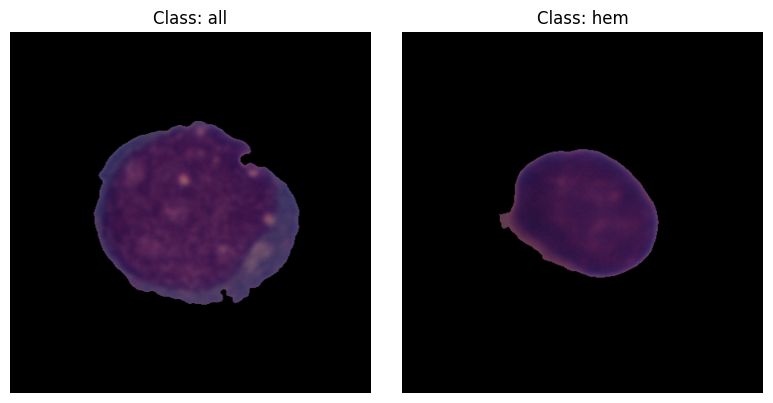

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

# Correct base path for the Leukemia Classification dataset
# We'll use 'fold_1' as an example, assuming similar structure across folds
base_path = 'brain_tumor_data/Leukemia Classification/training_data/fold_1'
# Correct categories for Leukemia Classification (Acute Lymphoblastic Leukemia and Healthy)
categories = ['all', 'hem']

plt.figure(figsize=(8, 4)) # Adjusted figure size for 2 categories

for i, cat in enumerate(categories):
    folder_path = os.path.join(base_path, cat)
    # Check if the folder exists before listing its contents
    if os.path.exists(folder_path):
        img_name = random.choice(os.listdir(folder_path))
        img_path = os.path.join(folder_path, img_name)

        img = Image.open(img_path)
        plt.subplot(1, 2, i + 1) # Adjusted subplot for 2 categories
        plt.imshow(img)
        plt.title(f"Class: {cat}")
        plt.axis('off')
    else:
        print(f"Warning: Folder not found: {folder_path}")

plt.tight_layout()
plt.show()

## **Data Visualization**

/tmp/ipython-input-721572617.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_stats, x='Category', y='Count', palette='magma')


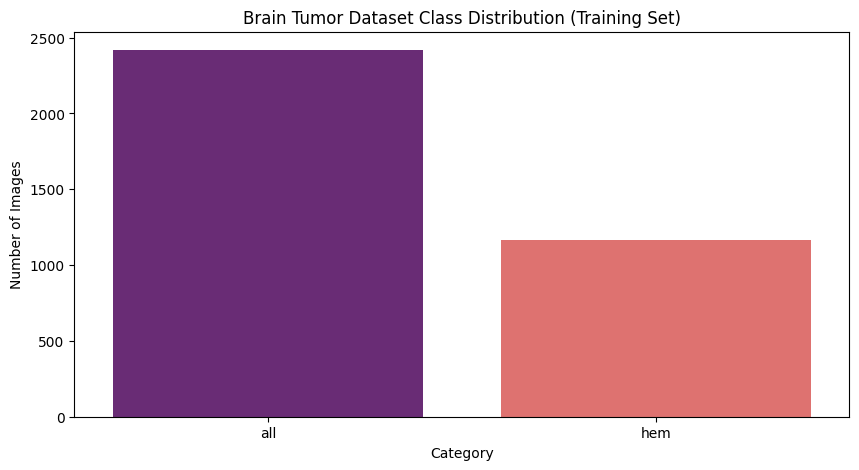

--- Dataset Statistics ---
  Category  Count
0      all   2418
1      hem   1163

Total Images: 3581


In [ ]:
import pandas as pd
import seaborn as sns

stats = []
for cat in categories:
    folder_path = os.path.join(base_path, cat)
    num_files = len(os.listdir(folder_path))
    stats.append({'Category': cat, 'Count': num_files})

df_stats = pd.DataFrame(stats)

# Visualizing class distribution
plt.figure(figsize=(10, 5))
sns.barplot(data=df_stats, x='Category', y='Count', palette='magma')
plt.title('Brain Tumor Dataset Class Distribution (Training Set)')
plt.ylabel('Number of Images')
plt.show()

# Print detailed info
print("--- Dataset Statistics ---")
print(df_stats)
print(f"\nTotal Images: {df_stats['Count'].sum()}")

# **Imports and Global Settings**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Configurations
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
# Ensure base_path points to your data folder
# base_path = 'brain_tumor_data/Leukemia Classification/training_data/fold_1'

# **Data Loading & Preprocessing**

In [ ]:
# Load Training Dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# Load Validation Dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# Optimization for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 3581 files belonging to 2 classes.
Using 2865 files for training.
Found 3581 files belonging to 2 classes.
Using 716 files for validation.


# **CNN Architecture**

In [ ]:
model = models.Sequential([
    # Rescale pixel values from [0, 255] to [0, 1]
    layers.Rescaling(1./255, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Prevents overfitting
    layers.Dense(1, activation='sigmoid') # Binary output: 0 (Healthy) or 1 (ALL)
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## **Evaluation & Inference Timing**

In [ ]:
start_train = time.time()

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

train_time = time.time() - start_train
print(f"\n[INFO] Total Training Time: {train_time:.2f} seconds")

Epoch 1/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 26s 146ms/step - accuracy: 0.7940 - loss: 0.4538 - precision: 0.7346 - recall: 0.5694 - val_accuracy: 0.8240 - val_loss: 0.4095 - val_precision: 0.7830 - val_recall: 0.6748
Epoch 2/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8407 - loss: 0.3889 - precision: 0.7959 - recall: 0.6677 - val_accuracy: 0.8240 - val_loss: 0.3969 - val_precision: 0.7941 - val_recall: 0.6585
Epoch 3/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8463 - loss: 0.3758 - precision: 0.8274 - recall: 0.6571 - val_accuracy: 0.8198 - val_loss: 0.3955 - val_precision: 0.7555 - val_recall: 0.7033
Epoch 4/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8372 - loss: 0.3731 - precision: 0.7977 - recall: 0.6590 - val_accuracy: 0.8198 - val_loss: 0.3971 - val_precision: 0.8031 - val_recall: 0.6301
Epoch 5/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8529 - loss: 0.3569 - precision: 0.8336 - recall: 0.6795 - val_accuracy: 0.8254 - val_loss: 0.404

In [ ]:
start_test = time.time()

y_true = []
y_pred_prob = []

# Iterate through validation set to collect labels and predictions
for images, labels in val_ds:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred_prob.extend(preds)

test_time = time.time() - start_test
y_pred = [1 if x > 0.5 else 0 for x in y_pred_prob]

print(f"[INFO] Total Test Time (Inference): {test_time:.2f} seconds")

[INFO] Total Test Time (Inference): 2.13 seconds


## **Metrics & Visualizations**


--- Detailed Classification Report ---
                precision    recall  f1-score   support

 Healthy (HEM)       0.83      0.93      0.88       470
Leukemia (ALL)       0.83      0.64      0.72       246

      accuracy                           0.83       716
     macro avg       0.83      0.79      0.80       716
  weighted avg       0.83      0.83      0.83       716



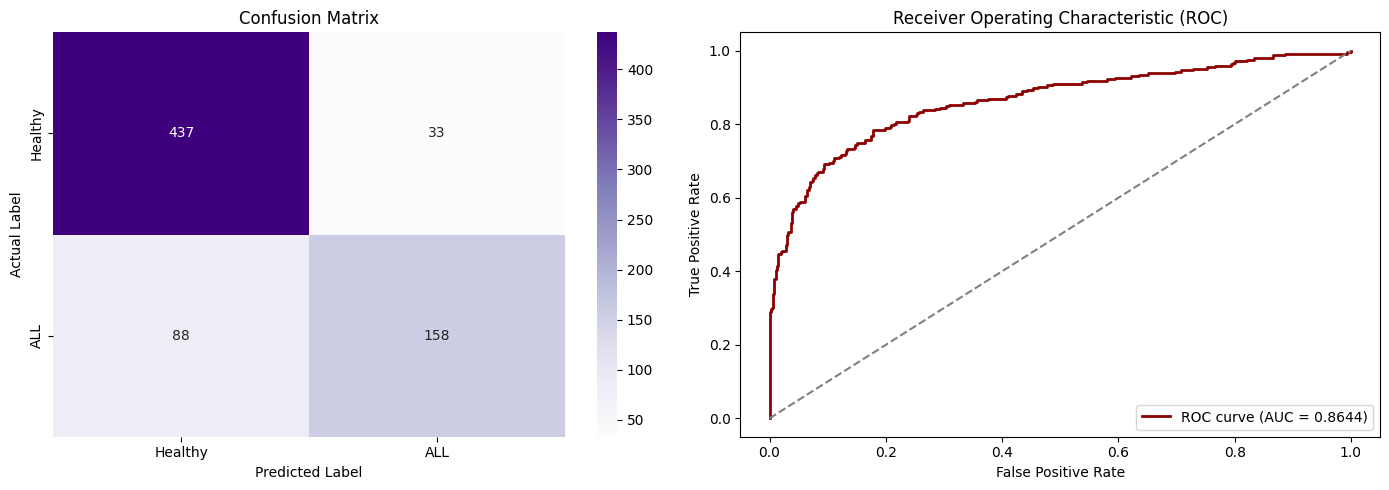

In [ ]:
# 1. Print Text-based Metrics (Accuracy, Precision, Recall, F1)
print("\n--- Detailed Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['Healthy (HEM)', 'Leukemia (ALL)']))

# 2. Plotting Results
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Plot
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax[0],
            xticklabels=['Healthy', 'ALL'], yticklabels=['Healthy', 'ALL'])
ax[0].set_title('Confusion Matrix')
ax[0].set_ylabel('Actual Label')
ax[0].set_xlabel('Predicted Label')

# ROC Curve Plot
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, color='darkred', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
ax[1].set_title('Receiver Operating Characteristic (ROC)')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# **Building VGG16 and ResNet50 Models**

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras import layers, models

def build_medical_model(model_name='VGG16', img_shape=(128, 128, 3)):
    if model_name == 'VGG16':
        base = VGG16(weights='imagenet', include_top=False, input_shape=img_shape)
    else:
        base = ResNet50(weights='imagenet', include_top=False, input_shape=img_shape)

    # Freeze the base layers to keep pre-trained knowledge
    base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Create both for comparison
vgg_model = build_medical_model('VGG16')
resnet_model = build_medical_model('ResNet50')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


## **Training Models**

In [ ]:
import time

results = {}

for name, model in [('VGG16', vgg_model), ('ResNet50', resnet_model)]:
    print(f"\n--- Training {name} ---")
    start = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=5, verbose=1)
    elapsed = time.time() - start
    results[name] = {'history': history, 'train_time': elapsed, 'model': model}


--- Training VGG16 ---
Epoch 1/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 23s 156ms/step - accuracy: 0.7347 - loss: 0.7522 - val_accuracy: 0.8226 - val_loss: 0.4410
Epoch 2/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.8428 - loss: 0.3864 - val_accuracy: 0.8352 - val_loss: 0.3854
Epoch 3/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.8673 - loss: 0.3531 - val_accuracy: 0.8003 - val_loss: 0.4257
Epoch 4/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.8615 - loss: 0.3556 - val_accuracy: 0.8338 - val_loss: 0.3989
Epoch 5/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.8544 - loss: 0.3486 - val_accuracy: 0.8352 - val_loss: 0.3852

--- Training ResNet50 ---
Epoch 1/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 26s 162ms/step - accuracy: 0.7453 - loss: 0.6725 - val_accuracy: 0.8184 - val_loss: 0.4088
Epoch 2/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8536 - loss: 0.3713 - val_accuracy: 0.8240 - val_loss: 0.3797
Epoch 3/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0

## **Evaluating Models**


[VGG16] Metrics:
Train Time: 47.78s | Test Time: 7.58s
              precision    recall  f1-score   support

     Healthy       0.82      0.95      0.88       470
         ALL       0.87      0.61      0.72       246

    accuracy                           0.84       716
   macro avg       0.85      0.78      0.80       716
weighted avg       0.84      0.84      0.83       716


[ResNet50] Metrics:
Train Time: 39.24s | Test Time: 10.84s
              precision    recall  f1-score   support

     Healthy       0.87      0.91      0.89       470
         ALL       0.80      0.74      0.77       246

    accuracy                           0.85       716
   macro avg       0.84      0.82      0.83       716
weighted avg       0.85      0.85      0.85       716



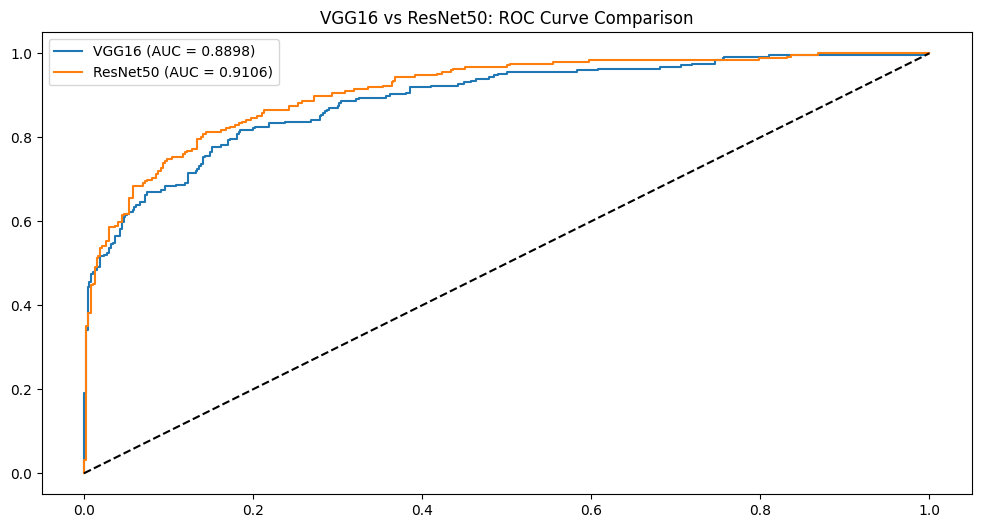

In [ ]:
from sklearn.metrics import classification_report, roc_curve, auc

plt.figure(figsize=(12, 6))

for name, data in results.items():
    # 1. Measure Inference (Test) Time
    start_test = time.time()
    y_true, y_probs = [], []
    for imgs, lbls in val_ds:
        y_true.extend(lbls.numpy())
        y_probs.extend(data['model'].predict(imgs, verbose=0))
    test_time = time.time() - start_test

    # 2. Process Metrics
    y_pred = [1 if x > 0.5 else 0 for x in y_probs]
    print(f"\n[{name}] Metrics:")
    print(f"Train Time: {data['train_time']:.2f}s | Test Time: {test_time:.2f}s")
    print(classification_report(y_true, y_pred, target_names=['Healthy', 'ALL']))

    # 3. Plot ROC Curves
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr, tpr):.4f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title('VGG16 vs ResNet50: ROC Curve Comparison')
plt.legend()
plt.show()

# **Model Explainability using Grad-Cam**

In [ ]:
# 1. Identify the last convolutional layer in ResNet50
# Standard name in tf.keras.applications.ResNet50 is 'conv5_block3_out'
last_conv_layer_name = "conv5_block3_out"

# 2. Grab a sample image from your validation set
# We take the first image from the first batch
for img_batch, label_batch in val_ds.take(1):
    img_to_test = img_batch[0:1] # Shape (1, 128, 128, 3)
    break

# 3. Generate the heatmap using the previously defined function
try:
    heatmap = get_gradcam_heatmap(resnet_model, img_to_test, last_conv_layer_name)

    # Display results
    plt.figure(figsize=(6, 6))
    plt.imshow(img_to_test[0].numpy().astype("uint8")) # Show original
    plt.imshow(heatmap, cmap='jet', alpha=0.5)        # Overlay heatmap
    plt.title(f"Grad-CAM: Highlighting Leukemia Features")
    plt.axis('off')
    plt.show()
except ValueError as e:
    print(f"Error: {e}")
    print("Check your model summary to find the correct layer name:")
    resnet_model.get_layer('resnet50').summary()

Error: No such layer: conv5_block3_out. Existing layers are: ['resnet50', 'global_average_pooling2d_1', 'dense_4', 'dropout_2', 'dense_5'].
Check your model summary to find the correct layer name:


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

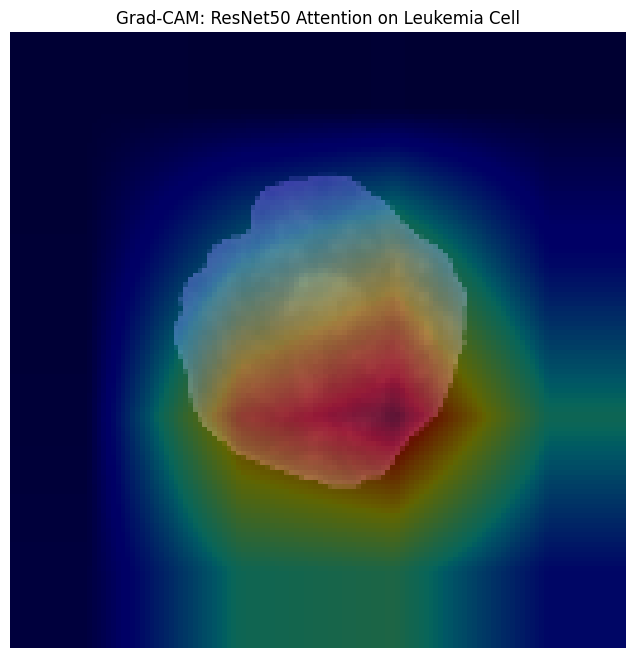

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def get_nested_gradcam(model, img_array, inner_model_name='resnet50', target_layer_name='conv5_block3_out'):
    # 1. Access the internal ResNet50 model
    inner_model = model.get_layer(inner_model_name)

    # 2. Create a model that maps ResNet50 input to the target conv layer AND the ResNet50 output
    # Note: We use inner_model.input and inner_model.output
    grad_model = tf.keras.models.Model(
        [inner_model.input],
        [inner_model.get_layer(target_layer_name).output, inner_model.output]
    )

    # 3. Get gradients
    with tf.GradientTape() as tape:
        # We must pass the image through the grad_model
        conv_outputs, predictions = grad_model(img_array)

        # Since your main model has more layers after ResNet (Dense/Dropout),
        # we need the final prediction from the WHOLE model to get the right gradient
        # However, for binary classification, we can just use the internal ResNet output
        # as a proxy for feature importance.
        class_channel = predictions[:, 0]

    # 4. Extract gradients
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 5. Build heatmap
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 6. Normalize
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# EXECUTION
# 1. Grab an image
for img_batch, label_batch in val_ds.take(1):
    img_to_test = img_batch[0:1]
    break

# 2. Generate Heatmap
heatmap = get_nested_gradcam(resnet_model, img_to_test)

# 3. Visualize
plt.figure(figsize=(8, 8))
plt.imshow(img_to_test[0].numpy().astype("uint8"))
# Resize heatmap to match image size and overlay
resized_heatmap = cv2.resize(heatmap, (128, 128))
plt.imshow(resized_heatmap, cmap='jet', alpha=0.4)
plt.title("Grad-CAM: ResNet50 Attention on Leukemia Cell")
plt.axis('off')
plt.show()

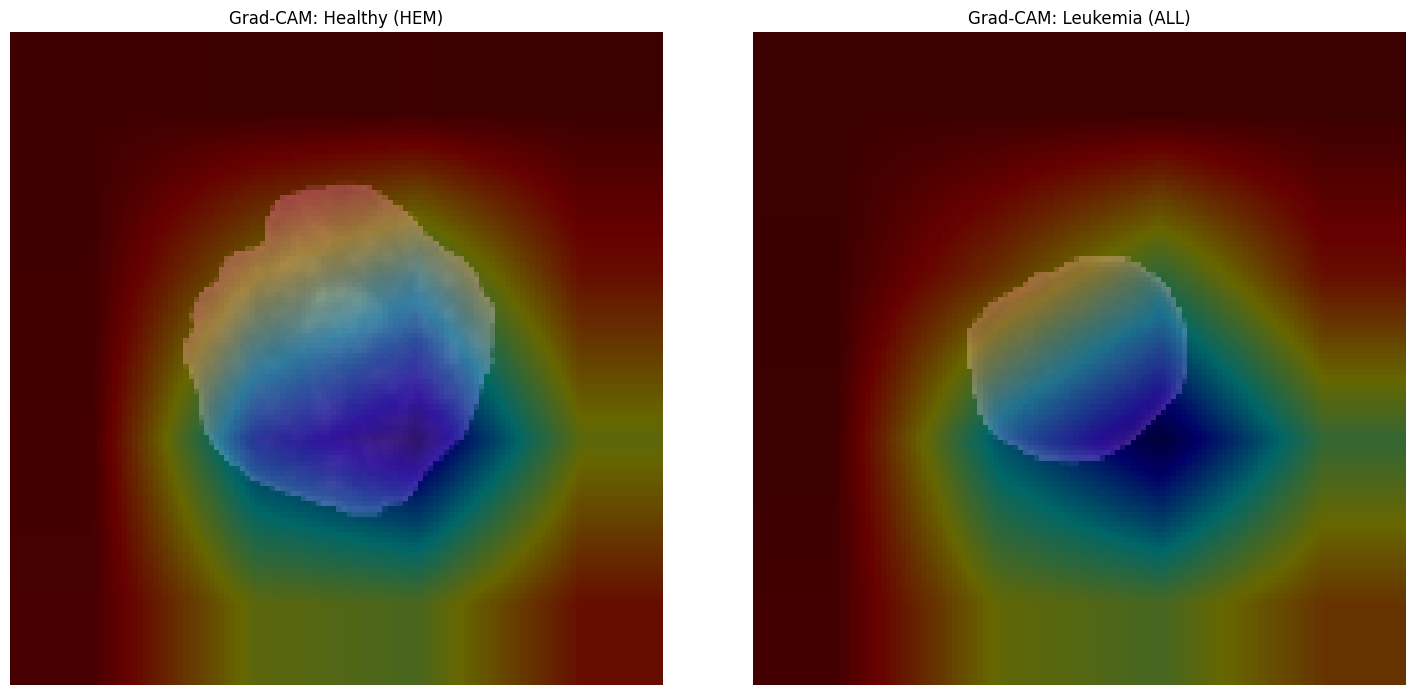

In [ ]:
import cv2

# 1. Helper to find one image of each class
def get_class_samples(dataset, target_labels=[0.0, 1.0]):
    samples = {label: None for label in target_labels}
    for imgs, labels in dataset.unbatch().batch(1):
        lbl = labels.numpy()[0][0]
        if lbl in samples and samples[lbl] is None:
            samples[lbl] = imgs
        if all(v is not None for v in samples.values()):
            break
    return samples

samples = get_class_samples(val_ds)

# 2. Plotting Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
class_names = {0.0: "Healthy (HEM)", 1.0: "Leukemia (ALL)"}

for i, (lbl, img) in enumerate(samples.items()):
    # Generate Heatmap
    heatmap = get_nested_gradcam(resnet_model, img)

    # Process for Overlay
    img_display = img[0].numpy().astype("uint8")
    heatmap_resized = cv2.resize(heatmap, (128, 128))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

    # Create Overlay
    overlay = cv2.addWeighted(img_display, 0.6, heatmap_color, 0.4, 0)

    axes[i].imshow(overlay)
    axes[i].set_title(f"Grad-CAM: {class_names[lbl]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()